## Multiple Subject Simulation

The issue with single-subject simulation is that their empirical relative value difference combinations by themselves are not meaningful. Only by collecting data from many subjects with varying parameters is the aDDM able to capture meaningful data, as evidence by Eum et al.'s approach (2023), and my own understanding of the pipeline.

Therefore, this notebook attempts to randomly sample the subjects and produce model-free analysis results consistent with published results. It should be that:

$$
\lim_{n \rightarrow S} \text{pooled model-free analysis} \approx \text{empirical model-free analysis}, \qquad S = \text{total number of subjects},\; n = \text{number of subjects in sample}
$$

I can also see this notebook going towards a direction of sampling procedure where sampling complementary pairs would be descriptive. In this case, we'd have to find a way to define complements in the aDDM space.

In [9]:
from ast import literal_eval
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_raw = pd.read_csv('/Users/braydenchien/Desktop/Enkavilab/DDM/1ms_trial_data.csv')
df_raw['RT'] = df_raw['RT']*1000 # adjustment for RT
df_raw['fixation'] = df_raw['fixation'].apply(literal_eval)

to_drop = pd.read_csv("dropped_trials.csv").rename(columns={"parcode": "sub_id"})

df = df_raw[
    ~df_raw.set_index(["sub_id", "trial"]).index.isin(
        to_drop.set_index(["sub_id", "trial"]).index
    )
]

# Randomly sample n subjects
sub_ids = np.unique(df["sub_id"])

rng = np.random.default_rng(seed=42)
n = 30
sample_sub_ids = np.random.choice(sub_ids, size=n, replace=False)

sample_df = df[df["sub_id"].isin(sample_sub_ids)]
sample_df.head()

,sub_id,trial,hidden,avgWTP_left,avgWTP_right,choice,RT,fixation
0,329,1,True,1.00,5.0,right,1723.0,"(4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ..."
1,329,2,True,3.00,5.0,left,2573.0,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,329,3,True,4.25,1.0,left,1775.0,"(4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ..."
3,329,4,True,3.50,1.0,left,1903.0,"(4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ..."
4,329,5,True,1.50,1.0,left,1863.0,"(4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ..."


In [10]:
from simulation import get_corrected_empirical_distributions

value_diffs = np.arange(-4, 4.25, 0.25)
legend = {
    "left": {1},
    "right": {2},
    "transition": {0}, 
    "blank_fixation": {4}
}
fixation_col = 'fixation'
left_value_col = 'avgWTP_left'
right_value_col = 'avgWTP_right'
cutoff = 0.95

empirical_distributions = get_corrected_empirical_distributions(
    sample_df,
    value_diffs=value_diffs,
    legend=legend,
    fixation_col=fixation_col,
    left_value_col=left_value_col,
    right_value_col=right_value_col,
    cutoff=cutoff
)

Check model-free analysis for the sample, and then once after the data is simulated.

/var/folders/59/03h51wmn6xn1jhvb7kj9fjc40000gn/T/ipykernel_20370/123411930.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df["choice"] = sample_df["choice"].map({"left": 0, "right": 1})
/Users/braydenchien/Desktop/Enkavilab/DDM/mfa.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = first_fix_df.groupby('diff_bin')['toward_larger'].agg(['mean', sem]).reset_index()
/Users/braydenchien/Desktop/Enkavilab/DDM/mfa.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pas

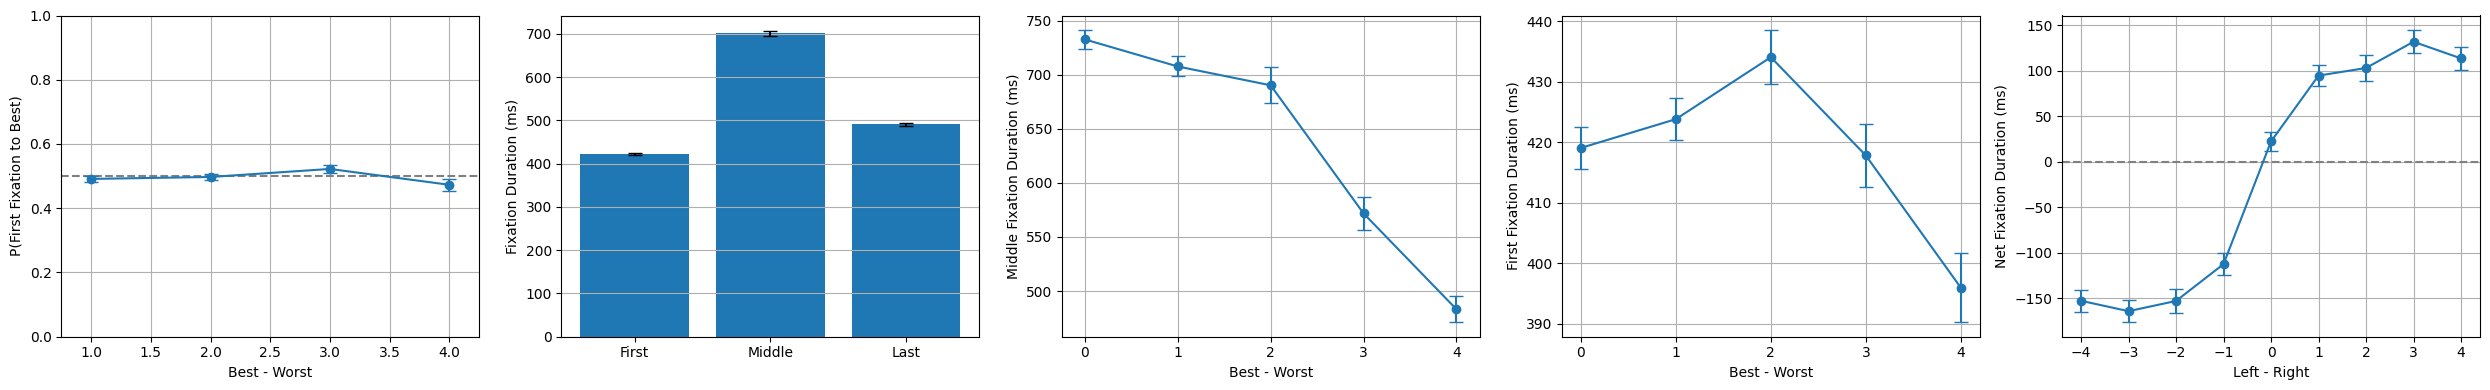

/Users/braydenchien/Desktop/Enkavilab/DDM/mfa.py:96: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prob_left_by_bin = first_fix_df.groupby('diff_bin')['choice'].apply(lambda x: (x == 0).mean())
/Users/braydenchien/Desktop/Enkavilab/DDM/mfa.py:97: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_centers = first_fix_df.groupby('diff_bin')['signed_diff'].mean()
/Users/braydenchien/Desktop/Enkavilab/DDM/mfa.py:110: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the futur

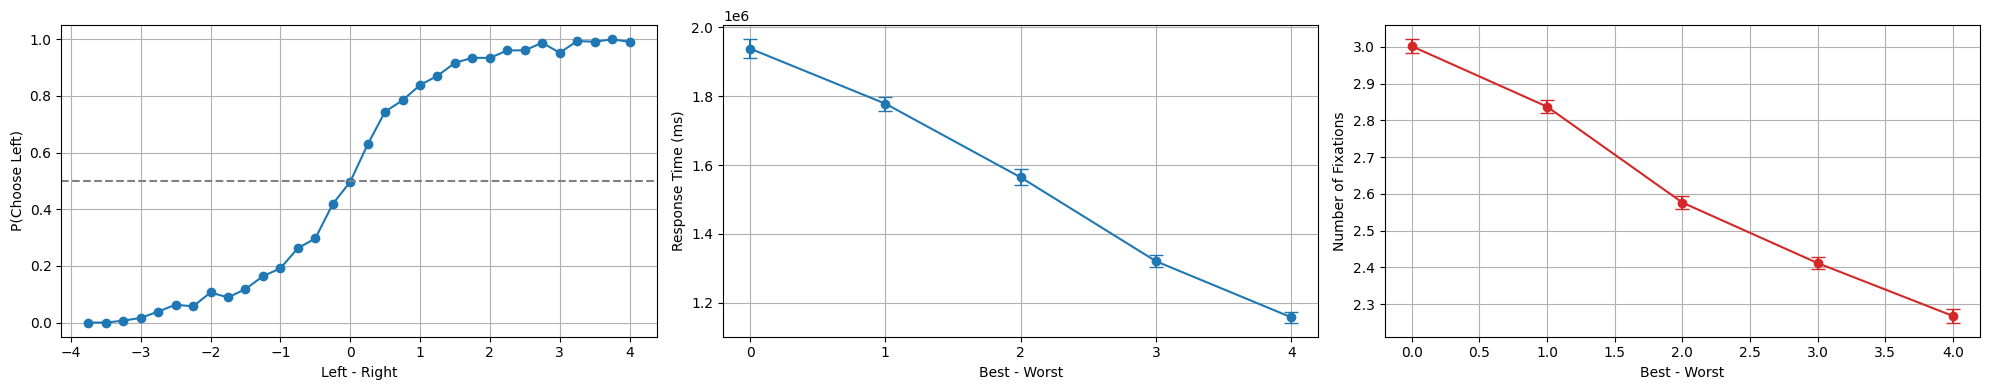

In [22]:
from mfa import plot_basic_psychometrics, plot_fixation_properties
from pyddm.preprocessing.dataset import rasterize_data

sample_df["choice"] = sample_df["choice"].map({"left": 0, "right": 1})

samples_rasterized = rasterize_data(sample_df, subject_col='sub_id',trial_col='trial',seq_col='fixation')

samples_rasterized['fix_dur'] = samples_rasterized.apply(
    lambda r: r['fix_end'] - r['fix_start'],
    axis=1
)

samples_rasterized['fix_num'] = (
    samples_rasterized
    .groupby(['sub_id', 'trial'])
    .cumcount() + 1
)

samples_rasterized['fix_num_rev'] = (
    samples_rasterized
    .groupby(['sub_id', 'trial'])
    .cumcount(ascending=False) + 1
)

plot_fixation_properties(samples_rasterized)
plot_basic_psychometrics(samples_rasterized)

Let's look at samples of size 15, 30, and 50.

/var/folders/59/03h51wmn6xn1jhvb7kj9fjc40000gn/T/ipykernel_20370/1373420686.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df["choice"] = sample_df["choice"].map({"left": 0, "right": 1})


Plotting model-free analysis of randomly sampled subjects size: 15:



/Users/braydenchien/Desktop/Enkavilab/DDM/mfa.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = first_fix_df.groupby('diff_bin')['toward_larger'].agg(['mean', sem]).reset_index()
/Users/braydenchien/Desktop/Enkavilab/DDM/mfa.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = middle_fix_df.groupby('diff_bin')['fix_dur'].agg(['mean', sem]).reset_index()
/Users/braydenchien/Desktop/Enkavilab/DDM/mfa.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to

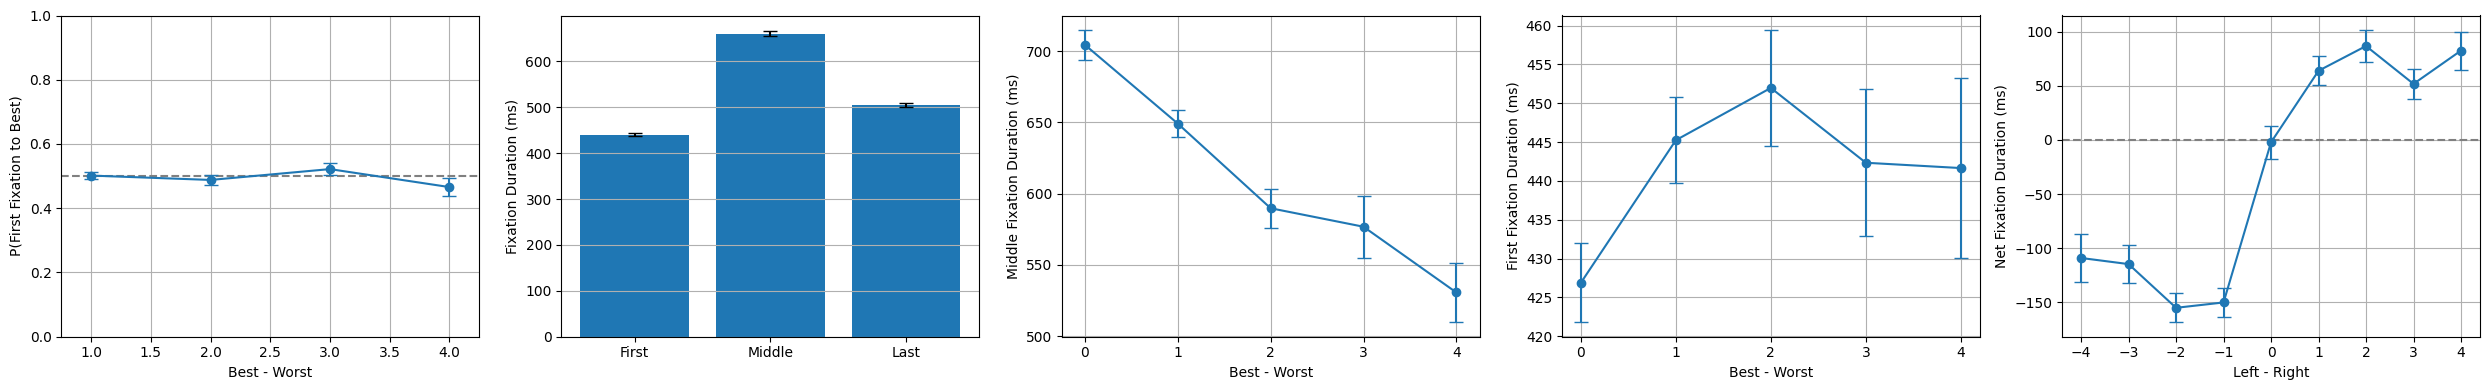

/Users/braydenchien/Desktop/Enkavilab/DDM/mfa.py:96: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prob_left_by_bin = first_fix_df.groupby('diff_bin')['choice'].apply(lambda x: (x == 0).mean())
/Users/braydenchien/Desktop/Enkavilab/DDM/mfa.py:97: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_centers = first_fix_df.groupby('diff_bin')['signed_diff'].mean()
/Users/braydenchien/Desktop/Enkavilab/DDM/mfa.py:110: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the futur

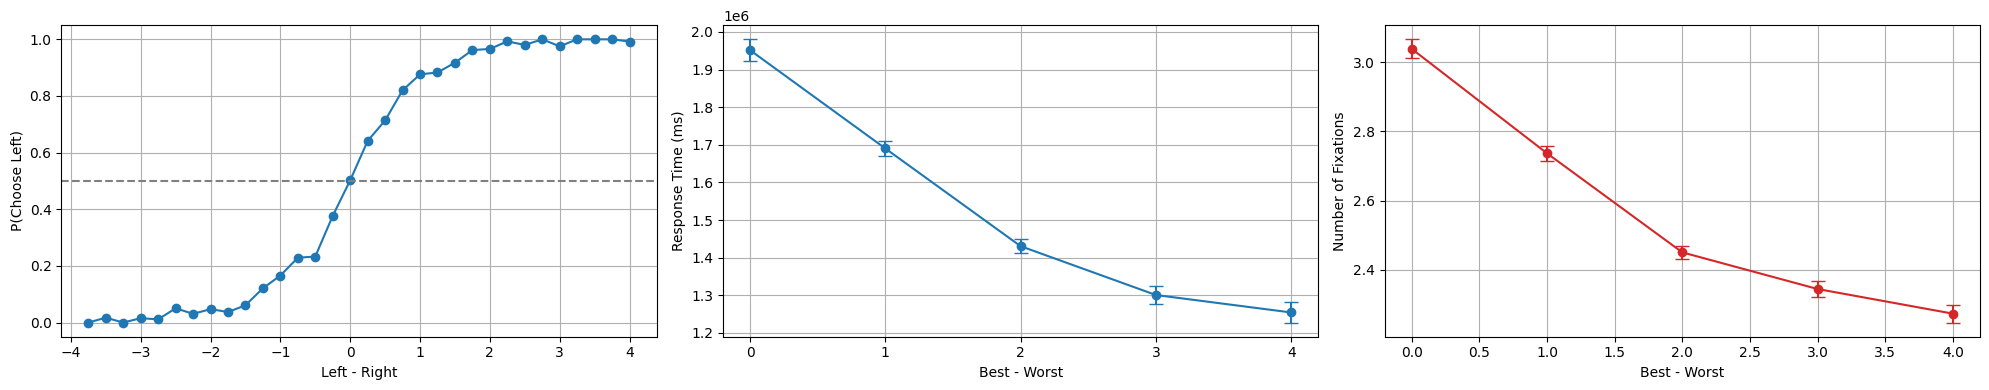

/var/folders/59/03h51wmn6xn1jhvb7kj9fjc40000gn/T/ipykernel_20370/1373420686.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df["choice"] = sample_df["choice"].map({"left": 0, "right": 1})


Plotting model-free analysis of randomly sampled subjects size: 15:



/Users/braydenchien/Desktop/Enkavilab/DDM/mfa.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = first_fix_df.groupby('diff_bin')['toward_larger'].agg(['mean', sem]).reset_index()
/Users/braydenchien/Desktop/Enkavilab/DDM/mfa.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = middle_fix_df.groupby('diff_bin')['fix_dur'].agg(['mean', sem]).reset_index()
/Users/braydenchien/Desktop/Enkavilab/DDM/mfa.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to

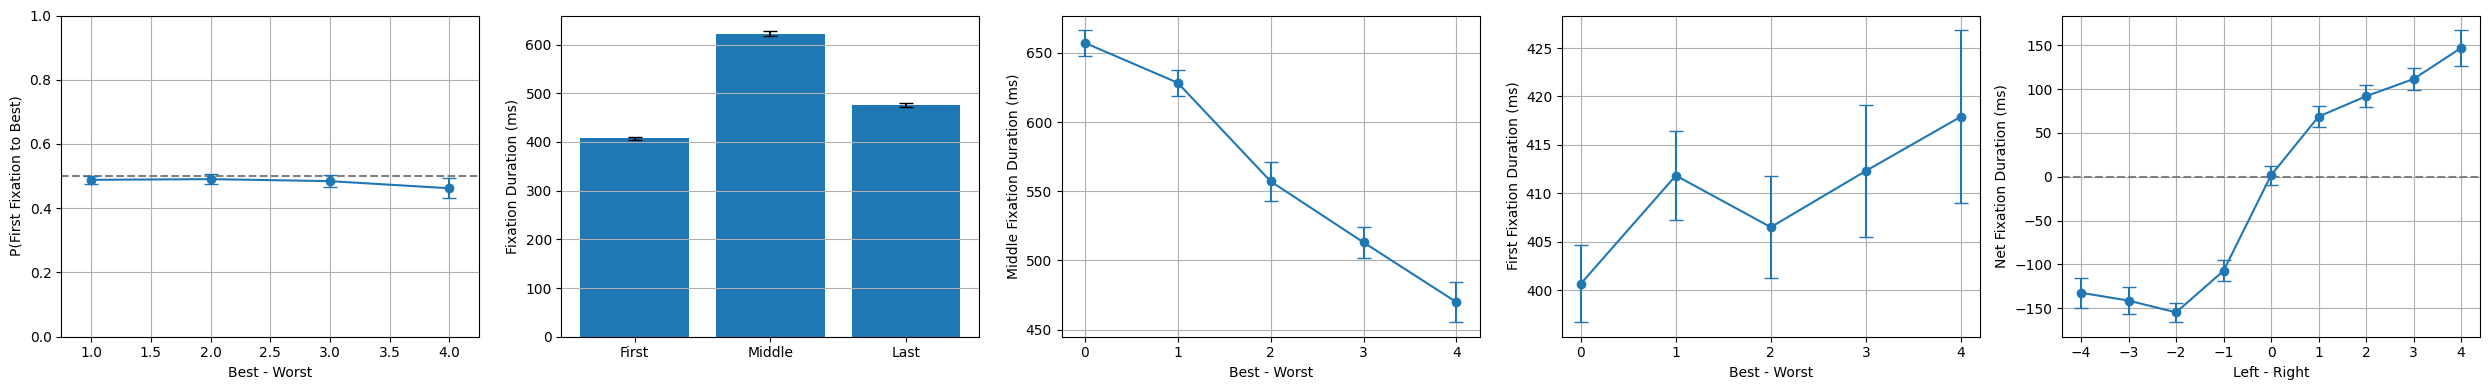

/Users/braydenchien/Desktop/Enkavilab/DDM/mfa.py:96: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prob_left_by_bin = first_fix_df.groupby('diff_bin')['choice'].apply(lambda x: (x == 0).mean())
/Users/braydenchien/Desktop/Enkavilab/DDM/mfa.py:97: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_centers = first_fix_df.groupby('diff_bin')['signed_diff'].mean()
/Users/braydenchien/Desktop/Enkavilab/DDM/mfa.py:110: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the futur

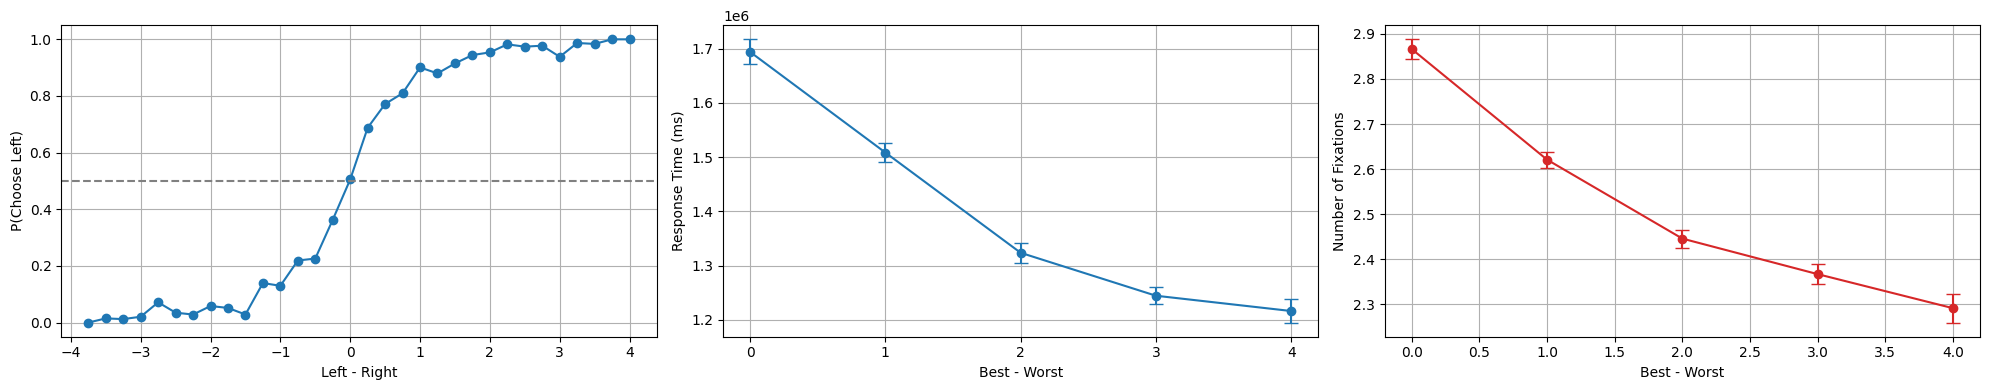

/var/folders/59/03h51wmn6xn1jhvb7kj9fjc40000gn/T/ipykernel_20370/1373420686.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df["choice"] = sample_df["choice"].map({"left": 0, "right": 1})


Plotting model-free analysis of randomly sampled subjects size: 15:



/Users/braydenchien/Desktop/Enkavilab/DDM/mfa.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = first_fix_df.groupby('diff_bin')['toward_larger'].agg(['mean', sem]).reset_index()
/Users/braydenchien/Desktop/Enkavilab/DDM/mfa.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = middle_fix_df.groupby('diff_bin')['fix_dur'].agg(['mean', sem]).reset_index()
/Users/braydenchien/Desktop/Enkavilab/DDM/mfa.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to

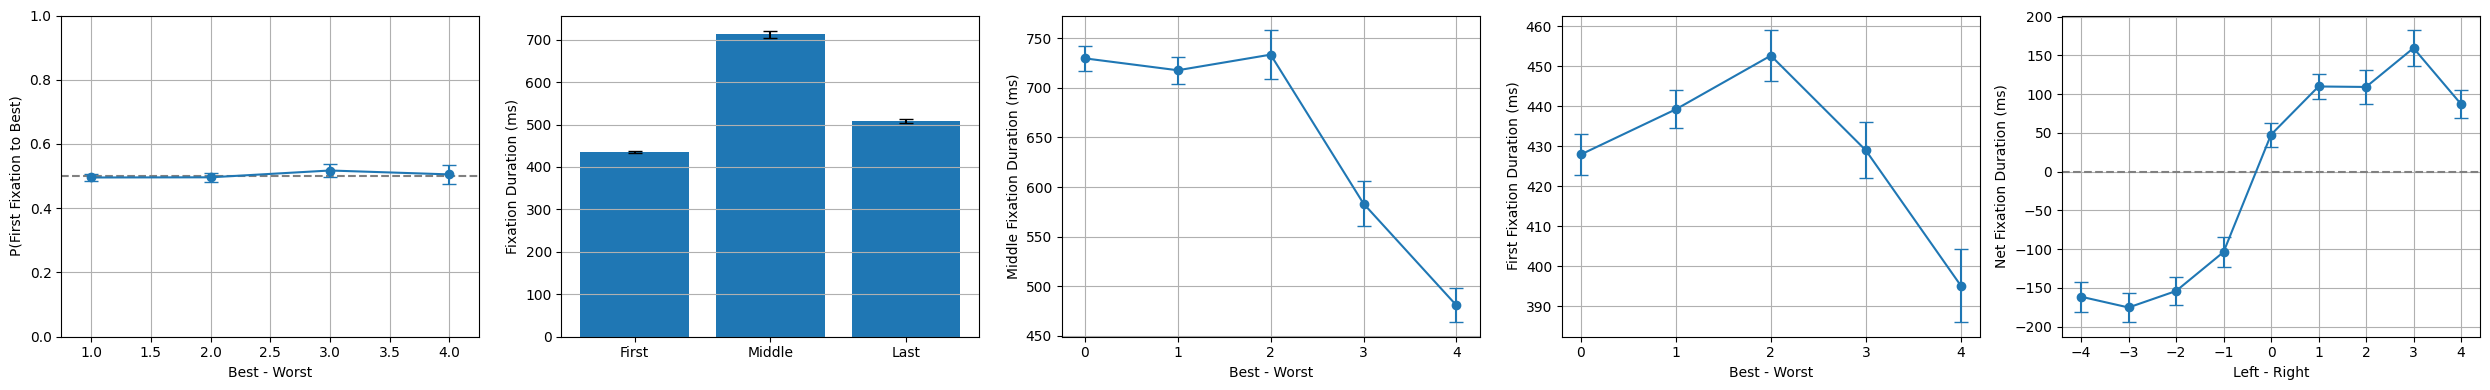

/Users/braydenchien/Desktop/Enkavilab/DDM/mfa.py:96: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prob_left_by_bin = first_fix_df.groupby('diff_bin')['choice'].apply(lambda x: (x == 0).mean())
/Users/braydenchien/Desktop/Enkavilab/DDM/mfa.py:97: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_centers = first_fix_df.groupby('diff_bin')['signed_diff'].mean()
/Users/braydenchien/Desktop/Enkavilab/DDM/mfa.py:110: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the futur

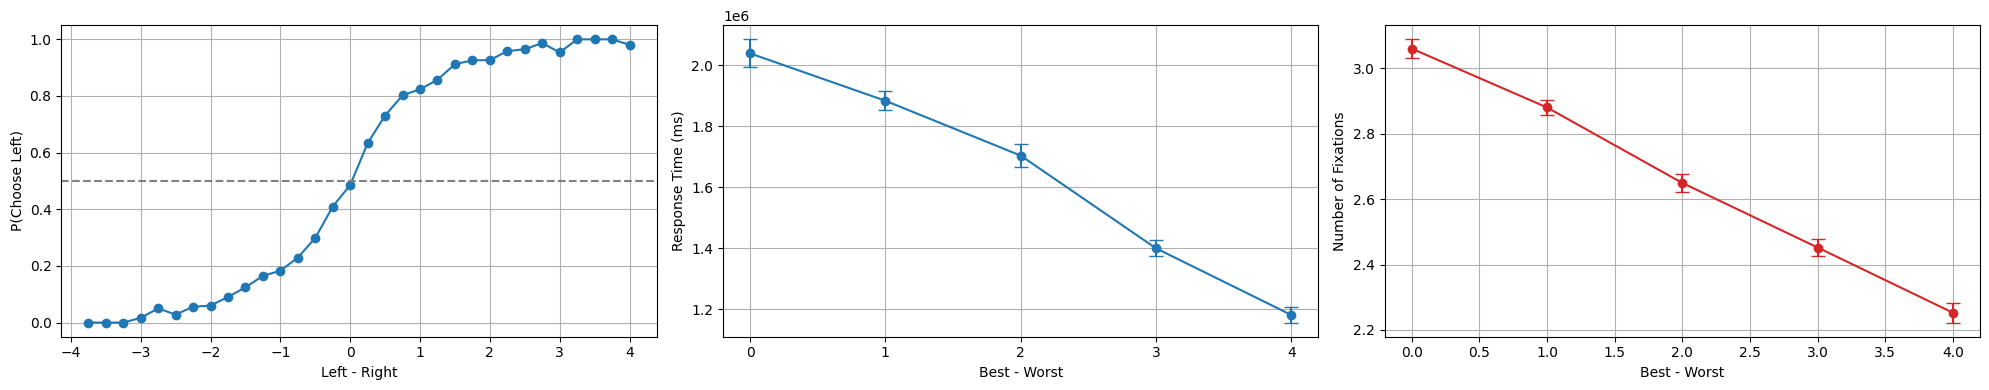

In [23]:
for size in ([15, 30, 50]):
    size = 15
    sample_sub_ids = np.random.choice(sub_ids, size=size, replace=False)

    sample_df = df[df["sub_id"].isin(sample_sub_ids)]

    sample_df["choice"] = sample_df["choice"].map({"left": 0, "right": 1})

    samples_rasterized = rasterize_data(sample_df, subject_col='sub_id',trial_col='trial',seq_col='fixation')

    samples_rasterized['fix_dur'] = samples_rasterized.apply(
        lambda r: r['fix_end'] - r['fix_start'],
        axis=1
    )

    samples_rasterized['fix_num'] = (
        samples_rasterized
        .groupby(['sub_id', 'trial'])
        .cumcount() + 1
    )

    samples_rasterized['fix_num_rev'] = (
        samples_rasterized
        .groupby(['sub_id', 'trial'])
        .cumcount(ascending=False) + 1
    )

    print(f'Plotting model-free analysis of randomly sampled subjects size: {size}:\n')
    plot_fixation_properties(samples_rasterized)
    plot_basic_psychometrics(samples_rasterized)